# Finding every kind of data for an area: the Querença-Silves aquifer

SNIRH has no concept of an "area". It publishes **networks** of **stations**, and it is up to you
to work out which stations fall inside the area you care about. This notebook does that end to
end for one real area — the **Querença-Silves aquifer** (SNIRH's `M5 - QUERENÇA - SILVES`), the
largest aquifer system in the Algarve — and pulls, maps and plots every kind of data SNIRH holds
for it: groundwater levels, spring discharge, groundwater chemistry, rainfall and river levels.

The general recipe, which transfers to any area:

1. **Locate the area** — find the handle SNIRH gives you (an aquifer name, or coordinates).
2. **Survey the networks** — ask every network which of its stations fall inside.
3. **Select stations** — by aquifer where the network names one, spatially where it does not.
4. **Discover parameters** — ask the stations themselves what they measure.
5. **Download, map and plot** each data type.

Everything here is fetched live from SNIRH, for **every station in the area** — no sampling,
because the spatial picture is the point. That costs a few hundred requests and several minutes;
read the politeness notes at the end before running it repeatedly.

> Needs `matplotlib` on top of the package's own dependencies (it is in `environment.yml`).

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from get_snirh import Snirh
from get_snirh.exceptions import SnirhDiscoveryError
from get_snirh.networks import fetch_networks
from get_snirh.client import SnirhClient

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 1000)
plt.rcParams["figure.dpi"] = 110
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.3

## 1. Locating the area

Groundwater networks tag each station with the aquifer system it belongs to, in the
`aquifer_system` column. That is the cleanest handle on an area SNIRH gives you, so start by
finding the exact string — the names carry accents and spacing you will not guess.

In [2]:
snirh_gw = Snirh("piezometria")
stations_gw = snirh_gw.stations()

aquifers = stations_gw["aquifer_system"].dropna().unique()
print(f"{len(aquifers)} aquifer systems named in the piezometria network.\n")

# Careful: 'QUER' alone also matches 'ALENQUER' and 'ESQUERDA'.
print("Matches for 'SILVES':", [a for a in aquifers if "SILVES" in a.upper()])

60 aquifer systems named in the piezometria network.

Matches for 'SILVES': ['M5 - QUERENÇA - SILVES']


In [3]:
AQUIFER = "M5 - QUERENÇA - SILVES"

area_gw = stations_gw[stations_gw["aquifer_system"] == AQUIFER]
print(f"{len(area_gw)} piezometria stations in {AQUIFER}\n")
print("Municipalities:", sorted(area_gw["municipality"].dropna().unique()))
print("River basins: ", sorted(area_gw["basin"].dropna().unique()))
print("\nStatus breakdown:")
print(area_gw["status"].value_counts().to_string())

70 piezometria stations in M5 - QUERENÇA - SILVES

Municipalities: ['ALBUFEIRA', 'LAGOA', 'LOULÉ', 'SILVES']
River basins:  ['ARADE', 'RIBEIRAS DO ALGARVE']

Status breakdown:
status
EM SERVIÇO    49
EM RESERVA     6
ABANDONADO     3


Note the area straddles two river basins and four municipalities. An aquifer is a hydrogeological
body; it does not respect administrative or surface-water boundaries. This is exactly why picking
the right handle matters.

Most networks do **not** have an `aquifer_system` column — only groundwater ones do. For the rest
we need a spatial filter, so derive a bounding box from the aquifer's own stations rather than
hardcoding coordinates.

In [4]:
BUFFER = 0.05  # degrees, roughly 5 km
LAT = (area_gw["latitude"].min() - BUFFER, area_gw["latitude"].max() + BUFFER)
LON = (area_gw["longitude"].min() - BUFFER, area_gw["longitude"].max() + BUFFER)

print(f"Aquifer extent : lat {area_gw['latitude'].min():.4f}..{area_gw['latitude'].max():.4f}, "
      f"lon {area_gw['longitude'].min():.4f}..{area_gw['longitude'].max():.4f}")
print(f"Search box     : lat {LAT[0]:.4f}..{LAT[1]:.4f}, lon {LON[0]:.4f}..{LON[1]:.4f}")

# Degrees of longitude shrink with latitude; fix the aspect so distances read true.
MAP_ASPECT = 1 / np.cos(np.radians(area_gw["latitude"].mean()))


def in_box(stations):
    '''Stations inside the search box. Coordinate-less networks return empty.'''
    if "latitude" not in stations.columns or stations["latitude"].isna().all():
        return stations.iloc[0:0]
    return stations[stations["latitude"].between(*LAT) & stations["longitude"].between(*LON)]


def basemap(ax, title):
    '''Shared map furniture: true aspect, box outline, labels.'''
    ax.add_patch(plt.Rectangle((LON[0], LAT[0]), LON[1] - LON[0], LAT[1] - LAT[0],
                               fill=False, ec="0.6", ls="--", lw=1, label="search box"))
    ax.set_aspect(MAP_ASPECT)
    ax.set_xlabel("longitude (°E)")
    ax.set_ylabel("latitude (°N)")
    ax.set_title(title)

Aquifer extent : lat 37.1525..37.2422, lon -8.4844..-7.9614
Search box     : lat 37.1025..37.2922, lon -8.5344..-7.9114


## 2. Which networks have data here?

Ask every network SNIRH publishes. This is the only honest way to find out what exists for an
area — there is no index to consult.

This cell fetches the station table for all 15 networks (roughly 50 sequential requests, a minute
or two). The tables are cached in `station_tables` and reused throughout, so this is the only
time we pay for them.

In [5]:
networks = fetch_networks(SnirhClient())

station_tables = {}
survey = []
for net in networks.itertuples(index=False):
    stations = Snirh(net.uid).stations()
    station_tables[net.slug] = stations
    has_aquifer = "aquifer_system" in stations.columns
    survey.append({
        "network": net.slug,
        "stations": len(stations),
        "names_aquifer": has_aquifer,
        "in_aquifer": int((stations["aquifer_system"] == AQUIFER).sum()) if has_aquifer else 0,
        "in_box": len(in_box(stations)),
    })

survey = pd.DataFrame(survey).sort_values("in_box", ascending=False).reset_index(drop=True)
survey

,network,stations,names_aquifer,in_aquifer,in_box
0,piezometria,1127,True,70,126
1,qualidade_aguas_subterraneas,1528,True,67,96
2,qualidade,4202,False,0,45
3,nascentes,83,True,18,26
4,hidrometrica,719,False,0,13
5,meteorologica,789,False,0,12
6,hidrometrica_algarve,29,False,0,11
7,sedimentologica,305,False,0,7
8,aguas_balneares,758,False,0,4
9,qualidade_automatica,112,False,0,2


Two things stand out.

**Only groundwater networks name the aquifer.** `piezometria`, `qualidade_aguas_subterraneas` and
`nascentes` carry `aquifer_system`; every other network is blank there and can only be filtered
spatially. That is not an oversight in this package — SNIRH simply does not tag a rain gauge with
an aquifer.

**Networks with zero hits are the Azores and Madeira ones**, plus `eta` (water-treatment plants),
which publishes no coordinates at all and so cannot be filtered spatially. If you need those,
municipality is the remaining handle.

### Mapping the stations

With coordinates in hand, plot what is actually there.

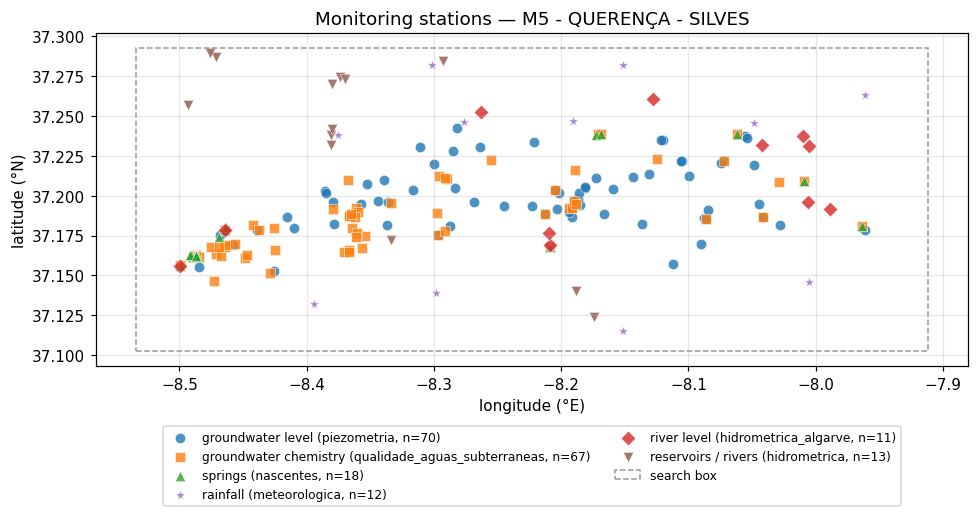

In [6]:
LAYERS = [
    ("piezometria",                  "aquifer", "o", "#1f77b4", "groundwater level"),
    ("qualidade_aguas_subterraneas", "aquifer", "s", "#ff7f0e", "groundwater chemistry"),
    ("nascentes",                    "aquifer", "^", "#2ca02c", "springs"),
    ("meteorologica",                "box",     "*", "#9467bd", "rainfall"),
    ("hidrometrica_algarve",         "box",     "D", "#d62728", "river level"),
    ("hidrometrica",                 "box",     "v", "#8c564b", "reservoirs / rivers"),
]

fig, ax = plt.subplots(figsize=(9, 6.5))
for slug, how, marker, colour, label in LAYERS:
    st = station_tables[slug]
    sel = st[st["aquifer_system"] == AQUIFER] if how == "aquifer" else in_box(st)
    if not len(sel):
        continue
    ax.scatter(sel["longitude"], sel["latitude"], marker=marker, c=colour, s=46,
               alpha=0.8, edgecolor="white", linewidth=0.4,
               label=f"{label} ({slug}, n={len(sel)})")

basemap(ax, f"Monitoring stations — {AQUIFER}")
ax.legend(loc="upper center", bbox_to_anchor=(0.5, -0.16), ncol=2, fontsize=8)
plt.tight_layout()
plt.show()

The groundwater stations (circles, squares, triangles) trace the aquifer body itself — a
west–east band. The rainfall, river and reservoir stations are simply whatever happens to fall in
the rectangle, which is the point of the next section.

## 3. The two selectors disagree — and that matters

For `piezometria` the aquifer gives 70 stations while the bounding box gives roughly twice as
many. They answer different questions:

- `aquifer_system == AQUIFER` means *"drilled into this body of rock"* — the hydrogeological truth.
- the bounding box means *"inside this rectangle"* — which sweeps in stations in neighbouring
  aquifers, and stations measuring something else entirely.

Where a network names the aquifer, **use that**. The box is a fallback for networks that leave you
no choice, and its results should be read as *candidates near the area*, not members of it.

In [7]:
box_gw = in_box(stations_gw)
overlap = set(area_gw["uid"]) & set(box_gw["uid"])

print(f"piezometria stations by aquifer name : {len(area_gw)}")
print(f"piezometria stations by bounding box : {len(box_gw)}")
print(f"in both                              : {len(overlap)}")
print(f"in the box but a DIFFERENT aquifer   : {len(box_gw) - len(overlap)}")

print("\nOther aquifers caught by the box:")
print(box_gw[~box_gw["uid"].isin(area_gw["uid"])]["aquifer_system"].value_counts().head(6).to_string())

piezometria stations by aquifer name : 70
piezometria stations by bounding box : 126
in both                              : 70
in the box but a DIFFERENT aquifer   : 56

Other aquifers caught by the box:
aquifer_system
M7 - QUARTEIRA                           14
M4 - FERRAGUDO - ALBUFEIRA               14
M0 - ORLA MERIDIONAL INDIFERENCIADO      13
M6 - ALBUFEIRA - RIBEIRA DE QUARTEIRA     7
M8 - S. BRÁS DE ALPORTEL                  5
A0 - MACIÇO ANTIGO INDIFERENCIADO         2


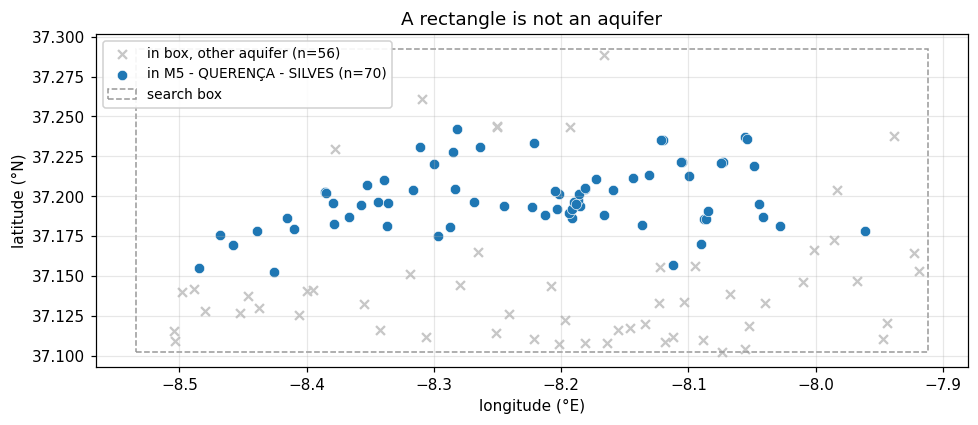

In [8]:
others = box_gw[~box_gw["uid"].isin(area_gw["uid"])]

fig, ax = plt.subplots(figsize=(9, 6.5))
ax.scatter(others["longitude"], others["latitude"], marker="x", c="#c7c7c7", s=34,
           label=f"in box, other aquifer (n={len(others)})")
ax.scatter(area_gw["longitude"], area_gw["latitude"], marker="o", c="#1f77b4", s=46,
           edgecolor="white", linewidth=0.4, label=f"in {AQUIFER} (n={len(area_gw)})")

basemap(ax, "A rectangle is not an aquifer")
ax.legend(loc="upper left", fontsize=9, framealpha=0.9)
plt.tight_layout()
plt.show()

The grey crosses are the cost of using a rectangle: real piezometers, correctly returned by a
spatial filter, that belong to other aquifers entirely. For the groundwater networks we can throw
them away by name. For rainfall and rivers we cannot — there, the rectangle is all we have.

## 4. Discovering what is actually measured

Two traps here, both worth internalising:

1. **`parameters()` lists what a station has *ever* measured**, not what it holds for your dates.
   A parameter can discover fine and return an empty frame for your window.
2. **Abandoned stations discover parameters but return no data.** Filter on `status` first —
   `EM SERVIÇO` (in service) for groundwater, `ATIVA` for meteorological stations.

In [9]:
active_gw = area_gw[area_gw["status"] == "EM SERVIÇO"]
print(f"{len(active_gw)} of {len(area_gw)} aquifer stations are EM SERVIÇO\n")

params_gw = snirh_gw.parameters(active_gw)
params_gw

49 of 70 aquifer stations are EM SERVIÇO



,uid,name
0,100290981,Nível piezométrico
1,2277,Profundidade Nível Água


## 5. Download, plot and map each data type

One network at a time, each contributing a different kind of observation about the same aquifer:

| Network | Selector | What it tells you |
|---|---|---|
| `piezometria` | aquifer | groundwater level — the state of the aquifer |
| `nascentes` | aquifer | spring discharge — water leaving the aquifer |
| `qualidade_aguas_subterraneas` | aquifer | chemistry — nitrate, chloride, conductivity |
| `meteorologica` | box | rainfall — water entering the system |
| `hidrometrica_algarve` | box | river level — surface water interaction |

Each returns the same long-format shape: `timestamp, code, uid, parameter, value`.

In [10]:
START, END = "2015-01-01", "2024-12-31"
datasets = {}


MAX_GAP = pd.Timedelta("90D")


def break_gaps(grp, max_gap=MAX_GAP):
    '''Insert NaN across long gaps.

    Without this, plot() draws a straight line between the last reading before
    a gap and the first one after it. That segment looks like data and is not:
    these records have real holes, and one station here switches from hourly to
    monthly mid-record. Never let a line imply readings that do not exist.
    '''
    s = grp.set_index("timestamp")["value"].sort_index()
    starts = s.index.to_series().diff() > max_gap
    if starts.any():
        blanks = pd.Series(np.nan, index=s.index[starts] - pd.Timedelta("1s"))
        s = pd.concat([s, blanks]).sort_index()
    return s


def plot_series(df, ax, ylabel, title, kind="line"):
    '''One line per station from a long-format get-snirh frame.'''
    for code, grp in df.groupby("code"):
        if kind == "line":
            s = break_gaps(grp)
            ax.plot(s.index, s.values, lw=0.9, label=code)
        else:
            grp = grp.sort_values("timestamp")
            ax.plot(grp["timestamp"], grp["value"], "o", ms=4, alpha=0.8, label=code)
    ax.set_ylabel(ylabel)
    ax.set_title(title)
    ax.legend(fontsize=8, ncol=2)

### 5.1 Groundwater level (`piezometria`)

In [11]:
# 'Nível piezométrico' (uid 100290981) = hydraulic head. Pass the DataFrame
# straight in: 'uid' drives the request, 'code' labels the rows.
# Every active station in the aquifer, not a sample.
head = snirh_gw.timeseries(active_gw, "100290981", start=START, end=END)
datasets["hydraulic_head"] = head

print(f"{len(head):,} rows from {head['code'].nunique()} of {len(active_gw)} stations requested")
print(f"span: {head['timestamp'].min():%Y-%m-%d} -> {head['timestamp'].max():%Y-%m-%d}")
head.head()

120,829 rows from 12 of 49 stations requested
span: 2015-01-01 -> 2024-12-03


,timestamp,code,uid,parameter,value
0,2015-01-07 00:00:00,595/212,100019,100290981,11.80
1,2015-02-11 11:40:00,595/212,100019,100290981,12.37
2,2015-03-10 11:35:00,595/212,100019,100290981,12.40
3,2015-04-09 11:25:00,595/212,100019,100290981,12.50
4,2015-05-18 11:50:00,595/212,100019,100290981,12.02


Note how few of the requested stations returned anything. That is normal and worth expecting:
being *in service* does not mean *publishing this parameter over these dates*.

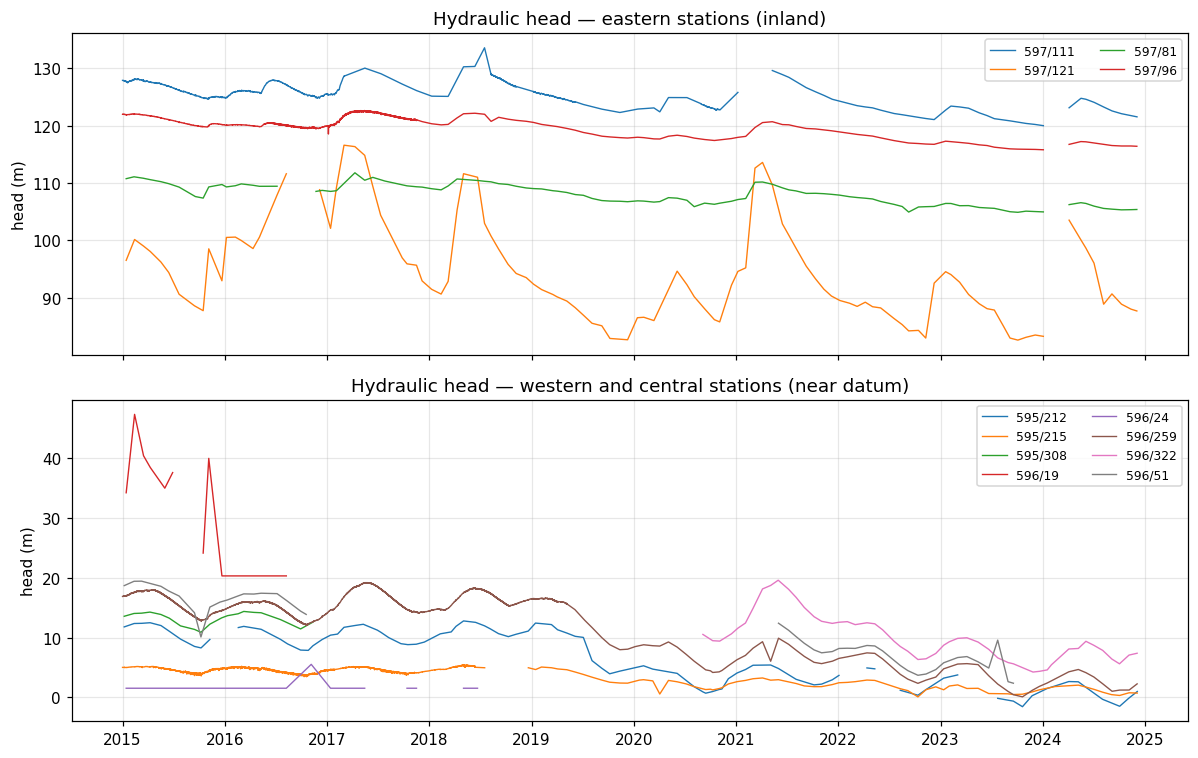

In [12]:
# Heads span two populations an order of magnitude apart (see the map below),
# so one axis would squash the low group -- which is where the action is.
mean_by_station = head.groupby("code")["value"].mean()
upper = mean_by_station[mean_by_station >= 50].index
lower = mean_by_station[mean_by_station < 50].index

fig, (ax_hi, ax_lo) = plt.subplots(2, 1, figsize=(11, 7), sharex=True)
plot_series(head[head["code"].isin(upper)], ax_hi, "head (m)",
            "Hydraulic head — eastern stations (inland)")
plot_series(head[head["code"].isin(lower)], ax_lo, "head (m)",
            "Hydraulic head — western and central stations (near datum)")
ax_lo.set_xlabel("")
plt.tight_layout()
plt.show()

### Why head, and not depth to water

`piezometria` offers both, and they are the same measurement seen two ways:

    hydraulic head = ground altitude − depth to water

For station 595/215, altitude is 63.76 m and depth runs 58.35–63.68 m, giving a head of
0.08–5.41 m. Identical information, but **only head is comparable between stations**, because
depth is measured from each station's own ground level while head shares a common datum. Two
piezometers a kilometre apart, both reading 40 m depth, tell you nothing about which way water
flows; their heads do. That is why the map below is possible at all — a map of depths would be a
map of topography.

Head is also the physically meaningful quantity: water flows down a head gradient, so this is what
goes into any water-balance or flow calculation. Use `2277` (*Profundidade Nível Água*) only when
you specifically want the depth from the ground, e.g. sizing a pump.

### Head in space

Because head shares a datum, it maps — and this is the payoff for asking every station in the
aquifer rather than a convenient handful. Water flows from high head to low.

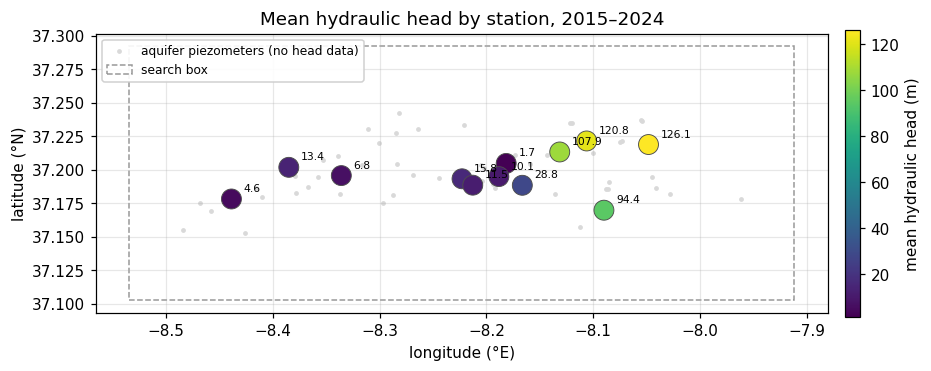

In [13]:
mean_head = head.groupby("code")["value"].mean().rename("mean_head").reset_index()
head_located = mean_head.merge(active_gw[["code", "latitude", "longitude"]], on="code", how="left")

fig, ax = plt.subplots(figsize=(9, 6.5))
ax.scatter(area_gw["longitude"], area_gw["latitude"], marker=".", c="0.85", s=18,
           label="aquifer piezometers (no head data)")
sc = ax.scatter(head_located["longitude"], head_located["latitude"], c=head_located["mean_head"],
                cmap="viridis", s=170, edgecolor="0.3", linewidth=0.6, zorder=3)
for r in head_located.itertuples(index=False):
    ax.annotate(f"{r.mean_head:.1f}", (r.longitude, r.latitude),
                textcoords="offset points", xytext=(8, 5), fontsize=7)

plt.colorbar(sc, ax=ax, label="mean hydraulic head (m)", shrink=0.42, pad=0.02)
basemap(ax, "Mean hydraulic head by station, 2015–2024")
ax.legend(loc="upper left", fontsize=8, framealpha=0.9)
plt.tight_layout()
plt.show()

There is the gradient: head is around 120 m at the eastern stations and single-digit metres in the
west, so groundwater moves **east to west**, toward the coast — with the western end sitting close
to datum. That is one figure, from one column, that a depth map could never have produced: plot
depth and you would mostly be plotting the height of the ground.

Take it as orientation, not a flow net. These are point measurements averaged over a decade during
which, as the next section shows, heads moved a long way.

### 5.2 Spring discharge (`nascentes`)

In [14]:
snirh_springs = Snirh("nascentes")
springs = station_tables["nascentes"]
springs_area = springs[springs["aquifer_system"] == AQUIFER]

flow = snirh_springs.timeseries(springs_area, "4183", start=START, end=END)  # Caudal
datasets["spring_discharge"] = flow

print(f"{len(springs_area)} springs in the aquifer; {len(flow):,} rows from {flow['code'].nunique()}")
flow.head()

18 springs in the aquifer; 345 rows from 12


,timestamp,code,uid,parameter,value
0,2015-01-29 00:00:00,587/23,100411,4183,0.86
1,2019-08-27 14:10:00,587/23,100411,4183,0.00
2,2020-07-20 12:00:00,587/23,100411,4183,0.81
3,2020-08-21 12:00:00,587/23,100411,4183,0.47
4,2020-09-17 00:00:00,587/23,100411,4183,0.38


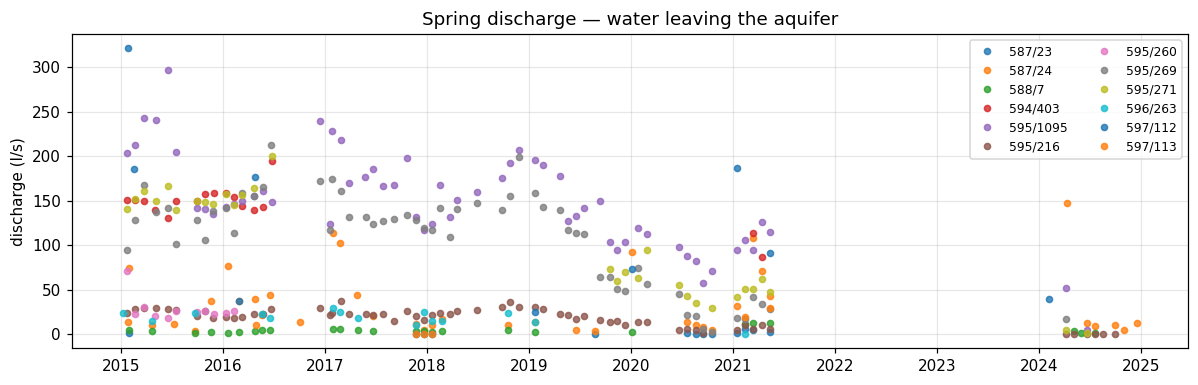

In [15]:
fig, ax = plt.subplots(figsize=(11, 3.6))
plot_series(flow, ax, "discharge (l/s)", "Spring discharge — water leaving the aquifer", kind="points")
ax.set_xlabel("")
plt.tight_layout()
plt.show()

### 5.3 Groundwater chemistry (`qualidade_aguas_subterraneas`)

In [16]:
snirh_chem = Snirh("qualidade_aguas_subterraneas")
chem_stations = station_tables["qualidade_aguas_subterraneas"]
chem_area = chem_stations[(chem_stations["aquifer_system"] == AQUIFER)
                          & (chem_stations["status"] == "EM SERVIÇO")]

# This network reports hundreds of determinands; search rather than scroll.
chem_params = snirh_chem.parameters(chem_area)
print(f"{len(chem_params)} parameters across all {len(chem_area)} active stations in the aquifer\n")
chem_params[chem_params["name"].str.contains("Nitrato|Cloreto|Condutividade", case=False, na=False)]

270 parameters across all 33 active stations in the aquifer



,uid,name
50,100003164,Cloreto (mg/l)
70,100003231,Condutividade (uS/cm)
71,100003222,Condutividade de campo a 20ºC (uS/cm)
72,100003225,Condutividade de laboratório a 20ºC (uS/cm)
159,100003461,Nitrato (mg/l NO3)


Read that list carefully — it is a trap. There are three conductivity entries, and the obvious
one, plain `Condutividade (uS/cm)`, returns **nothing** for these stations. The data lives under
`Condutividade de laboratório a 20ºC`. Discovery tells you a parameter exists at a station; it
does not promise the station ever published values for it. Always check the row count.

In [17]:
DETERMINANDS = {
    "nitrate":      ("100003461", "Nitrato",       "mg/l NO3"),
    "chloride":     ("100003164", "Cloreto",       "mg/l"),
    "conductivity": ("100003225", "Condutividade (lab, 20ºC)", "µS/cm"),
}

for name, (uid, label, unit) in DETERMINANDS.items():
    # every active chemistry station in the aquifer
    df = snirh_chem.timeseries(chem_area, uid, start=START, end=END)
    datasets[name] = df
    print(f"{label:28} {len(df):3} samples, {df['code'].nunique()} stations, "
          f"{df['value'].min():.0f}-{df['value'].max():.0f} {unit}")

# The empty one, for contrast — same call, same stations, no data.
empty_ec = snirh_chem.timeseries(chem_area, "100003231", start=START, end=END)
print(f"\n{'Condutividade (plain)':28} {len(empty_ec):3} samples  <- discovers, never returns data")

Nitrato                      133 samples, 8 stations, 1-100 mg/l NO3


Cloreto                      131 samples, 8 stations, 19-230 mg/l


Condutividade (lab, 20ºC)    133 samples, 8 stations, 270-1300 µS/cm



Condutividade (plain)          0 samples  <- discovers, never returns data


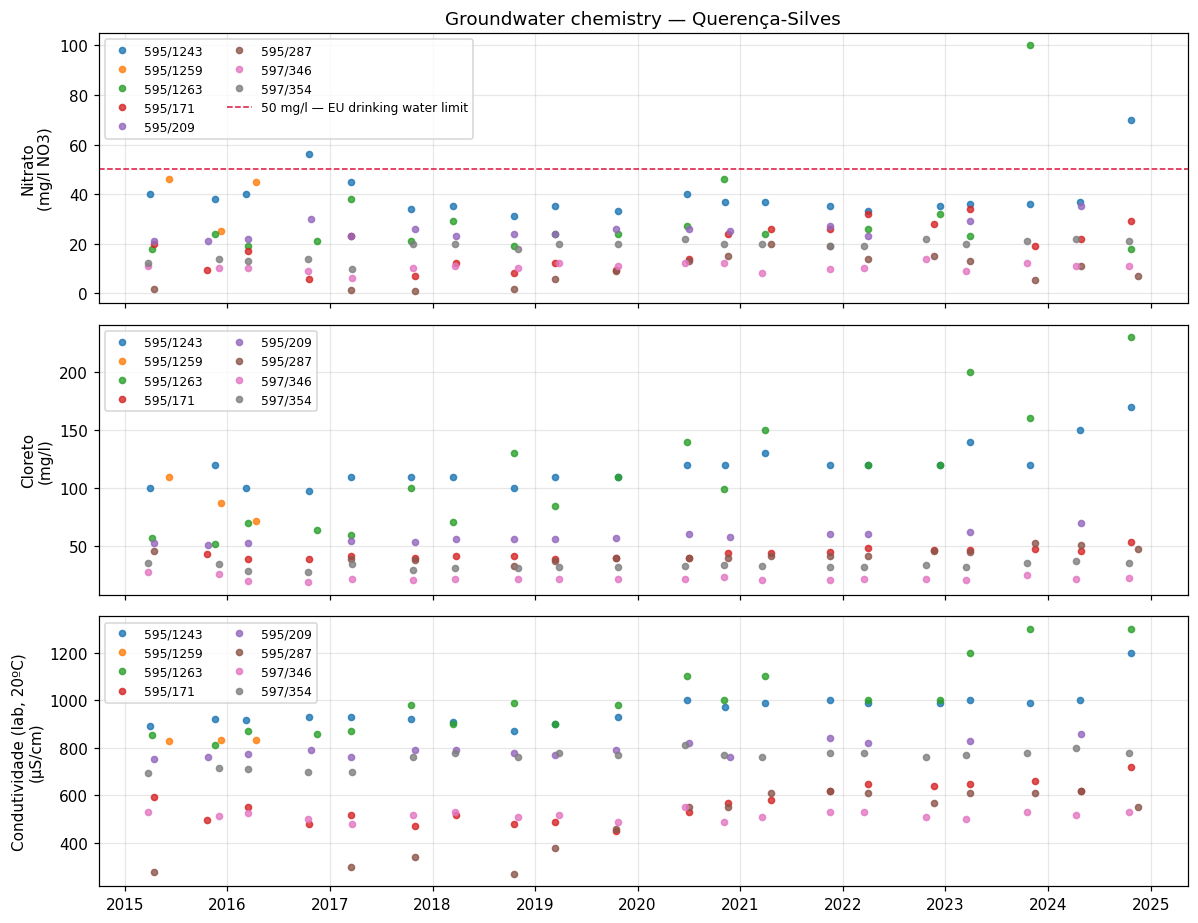

In [18]:
fig, axes = plt.subplots(3, 1, figsize=(11, 8.5), sharex=True)
for ax, (name, (uid, label, unit)) in zip(axes, DETERMINANDS.items()):
    plot_series(datasets[name], ax, f"{label}\n({unit})", "", kind="points")
    ax.set_title("")

axes[0].axhline(50, color="crimson", ls="--", lw=1,
                label="50 mg/l — EU drinking water limit")
axes[0].legend(fontsize=8, ncol=2)
axes[0].set_title("Groundwater chemistry — Querença-Silves", fontsize=12)
axes[-1].set_xlabel("")
plt.tight_layout()
plt.show()

Nitrate at some stations sits at or above the 50 mg/l EU drinking-water limit — Querença-Silves is
a designated nitrate-vulnerable zone, and this is what that designation looks like in the raw
data. Chloride and conductivity move together, as they should: conductivity is largely a proxy for
dissolved salts.

Sampling data is sparse and irregular — a handful of samples per station per year, not a
timeseries in the instrument sense. The shape is identical, but do not read the gaps as missing
data; they are simply when nobody sampled.

### Chemistry in space

A timeseries hides *where* the problem is. Join the samples back to the station coordinates.

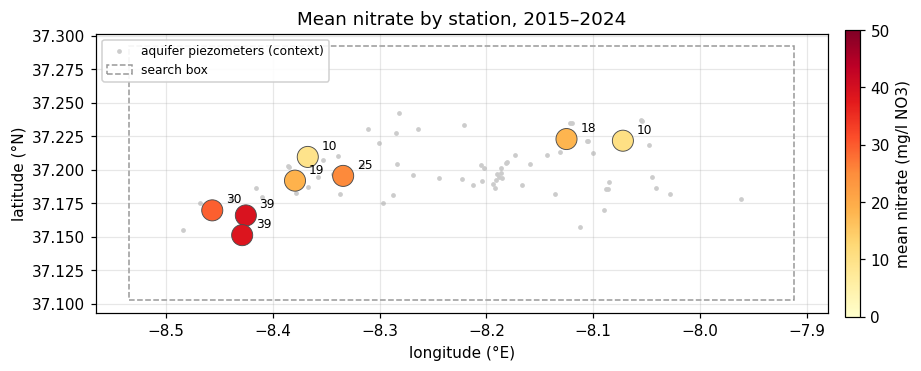

In [19]:
mean_no3 = (datasets["nitrate"].groupby("code")["value"].mean()
            .rename("mean_nitrate").reset_index())
located = mean_no3.merge(chem_area[["code", "latitude", "longitude"]], on="code", how="left")

fig, ax = plt.subplots(figsize=(9, 6.5))
ax.scatter(area_gw["longitude"], area_gw["latitude"], marker=".", c="0.8", s=18,
           label="aquifer piezometers (context)")
sc = ax.scatter(located["longitude"], located["latitude"], c=located["mean_nitrate"],
                cmap="YlOrRd", s=190, edgecolor="0.3", linewidth=0.6,
                vmin=0, vmax=max(50, located["mean_nitrate"].max()), zorder=3)
for r in located.itertuples(index=False):
    ax.annotate(f"{r.mean_nitrate:.0f}", (r.longitude, r.latitude),
                textcoords="offset points", xytext=(9, 5), fontsize=8)

plt.colorbar(sc, ax=ax, label="mean nitrate (mg/l NO3)", shrink=0.42, pad=0.02)
basemap(ax, "Mean nitrate by station, 2015–2024")
ax.legend(loc="upper left", fontsize=8, framealpha=0.9)
plt.tight_layout()
plt.show()

### 5.4 Rainfall (`meteorologica`)

In [20]:
snirh_meteo = Snirh("meteorologica")
meteo_area = in_box(station_tables["meteorologica"])
meteo_active = meteo_area[meteo_area["status"] == "ATIVA"]

# Monthly, not hourly: hourly rainfall for this box is ~600k rows.
rain = snirh_meteo.timeseries(meteo_active, "1436794570", start=START, end=END)
datasets["rainfall_monthly"] = rain

print(f"{len(meteo_active)} active gauges in the box; {len(rain):,} monthly totals "
      f"from {rain['code'].nunique()}")
rain.head()

9 active gauges in the box; 712 monthly totals from 9


,timestamp,code,uid,parameter,value
0,2015-05-01 09:00:00,30G/03C,920685086,1436794570,0.1
1,2015-06-01 09:00:00,30G/03C,920685086,1436794570,4.9
2,2015-07-01 09:00:00,30G/03C,920685086,1436794570,1.2
3,2015-08-01 09:00:00,30G/03C,920685086,1436794570,1.0
4,2015-09-01 09:00:00,30G/03C,920685086,1436794570,6.0


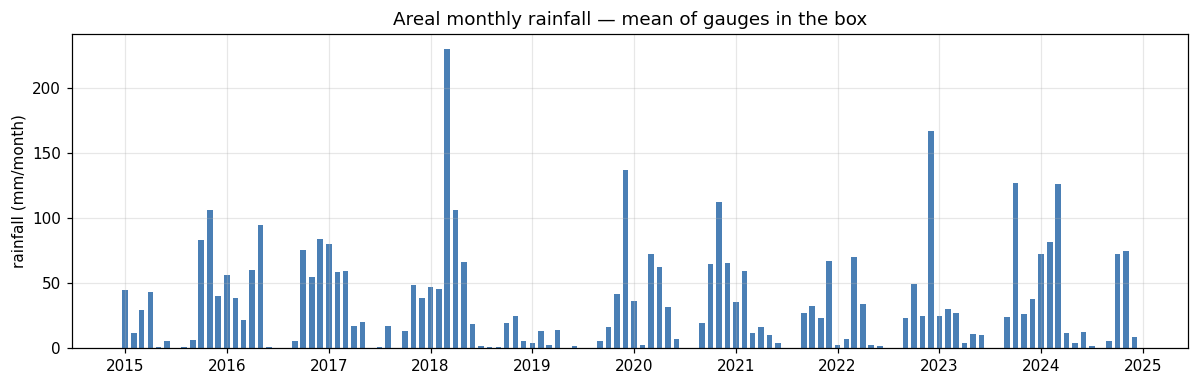

In [21]:
# Average across gauges: a single areal rainfall signal for the box.
areal = rain.groupby("timestamp")["value"].mean()

fig, ax = plt.subplots(figsize=(11, 3.6))
ax.bar(areal.index, areal.values, width=20, color="#4a7fb5")
ax.set_ylabel("rainfall (mm/month)")
ax.set_title("Areal monthly rainfall — mean of gauges in the box")
plt.tight_layout()
plt.show()

### 5.5 River level (`hidrometrica_algarve`)

In [22]:
snirh_river = Snirh("hidrometrica_algarve")
river_area = in_box(station_tables["hidrometrica_algarve"])

# Some stations have no parameters at all, which raises rather than returning empty.
try:
    river_params = snirh_river.parameters(river_area)
    print(f"{len(river_params)} parameters across {len(river_area)} stations in the box")
except SnirhDiscoveryError as exc:
    print("No parameters discoverable:", exc)

level = snirh_river.timeseries(river_area, "1845", start=START, end=END)  # Nível médio diário
datasets["river_level_daily"] = level

print(f"\n{len(level):,} daily levels from {level['code'].nunique()} stations")
level.head()

4 parameters across 11 stations in the box



10,989 daily levels from 8 stations


,timestamp,code,uid,parameter,value
0,2015-07-01,30H/01HA,2191495712,1845,0.12
1,2015-07-02,30H/01HA,2191495712,1845,0.16
2,2015-07-03,30H/01HA,2191495712,1845,0.15
3,2015-07-04,30H/01HA,2191495712,1845,0.15
4,2015-07-05,30H/01HA,2191495712,1845,0.13


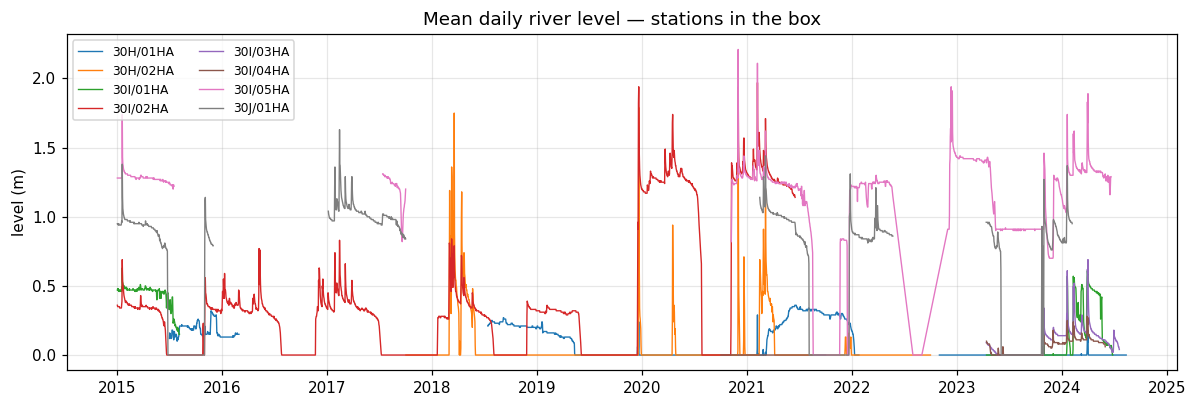

In [23]:
fig, ax = plt.subplots(figsize=(11, 3.8))
plot_series(level, ax, "level (m)", "Mean daily river level — stations in the box")
ax.set_xlabel("")
plt.tight_layout()
plt.show()

These are Algarve streams: flashy winter peaks and long flat spells at zero. The lines break where
a station stopped reporting for more than 90 days — that is `break_gaps()` doing its job. Plot
these frames naively and `plot()` will span each hole with a straight diagonal that reads as a
slow, smooth trend and is entirely an artefact. It is the single easiest way to publish a chart of
something that never happened.

## 6. Rainfall against groundwater

The point of collecting different data types for one area is comparing them. Rainfall is the input
to the aquifer; groundwater level is its state. Stack them on a shared time axis — two networks,
selected two different ways, describing one aquifer.

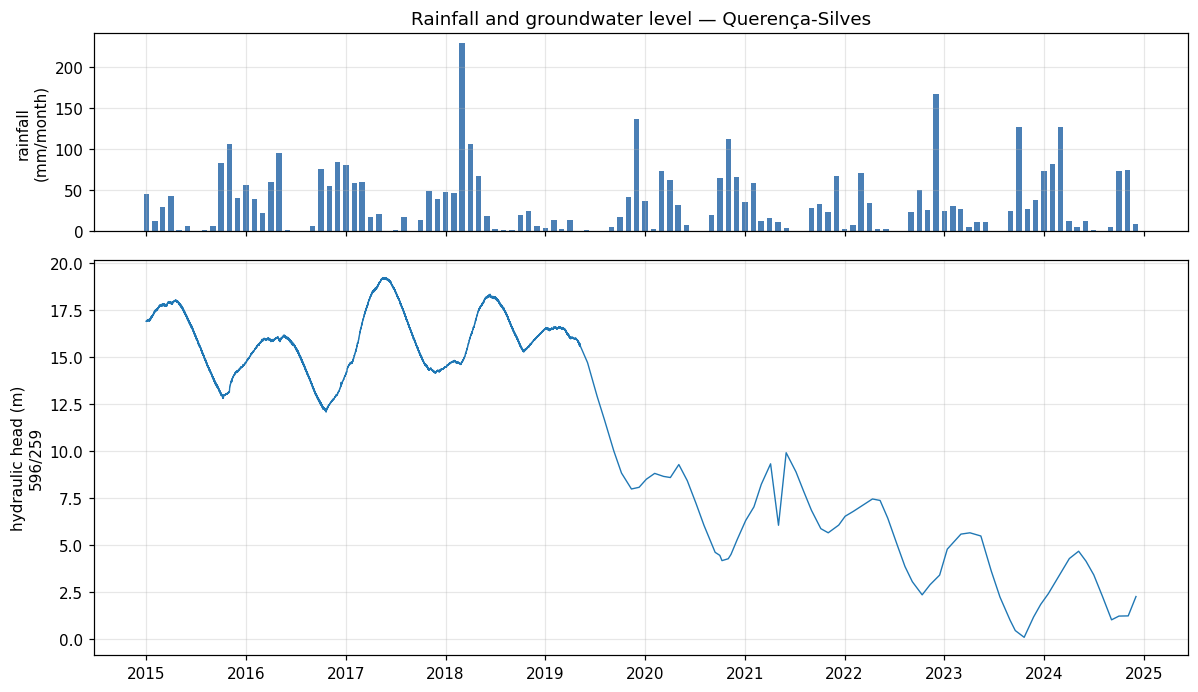

In [24]:
best = head.groupby("code")["value"].count().idxmax()   # best-covered station
series = head[head["code"] == best].sort_values("timestamp")

fig, (ax_rain, ax_gwl) = plt.subplots(2, 1, figsize=(11, 6.4), sharex=True,
                                      gridspec_kw={"height_ratios": [1, 2]})

ax_rain.bar(areal.index, areal.values, width=20, color="#4a7fb5")
ax_rain.set_ylabel("rainfall\n(mm/month)")
ax_rain.set_title("Rainfall and groundwater level — Querença-Silves")

head_series = break_gaps(series)          # do not bridge the 2018/19 changeover
ax_gwl.plot(head_series.index, head_series.values, color="#1f77b4", lw=0.9)
ax_gwl.set_ylabel(f"hydraulic head (m)\n{best}")
ax_gwl.set_xlabel("")
plt.tight_layout()
plt.show()

Read this one carefully, because it contains a trap that has nothing to do with hydrology.

The curve is **noisy until 2018 and smooth afterwards**. That is not the aquifer calming down — it
is the monitoring programme changing. Count the readings per year and the artefact is obvious:

In [25]:
per_year = series.groupby(series["timestamp"].dt.year)["value"].agg(
    readings="size", mean_head="mean", lowest="min", highest="max").round(2)
per_year

,readings,mean_head,lowest,highest
timestamp,,,,
2015,8769,15.77,12.80,18.02
2016,8794,14.58,12.08,16.16
2017,8770,16.53,14.12,19.22
2018,8767,16.35,14.46,18.34
2019,3052,16.30,7.98,16.60
2020,15,6.52,4.17,9.28
2021,12,7.34,5.65,9.91
2022,11,5.01,2.35,7.45
2023,12,3.08,0.09,5.65


Roughly 8,700 readings a year through 2018 — hourly logging — then about 12 a year: monthly dips.
Same station, same parameter, same `uid`; a completely different record. The fine seasonal
sawtooth in the early years is simply resolved by hourly data, and invisible at monthly sampling.
Nothing in the data announces this. If you averaged naively across the record, or fitted anything
assuming even sampling, you would be fooled.

What *is* real, and survives the sampling change, is the trend: mean head at this station falls
from about 15.8 m in 2015 to about 2.7 m in 2024 — roughly **13 m of head lost** across the
decade. The 2023 minimum is 0.09 m: effectively at datum.

Is that one bad station, or the aquifer? This is the question fetching *every* station lets you
answer, so answer it rather than eyeballing the plot.

In [26]:
by_station = []
for code, grp in head.groupby("code"):
    annual = grp.groupby(grp["timestamp"].dt.year)["value"].mean()
    if len(annual) < 3:          # too short a record to read a trend from
        continue
    by_station.append({"code": code, "years": f"{annual.index[0]}-{annual.index[-1]}",
                       "first": annual.iloc[0], "last": annual.iloc[-1],
                       "change_m": annual.iloc[-1] - annual.iloc[0]})

trend = pd.DataFrame(by_station).sort_values("first").round(1).reset_index(drop=True)
print(f"{(trend['change_m'] < 0).sum()} of {len(trend)} stations lost head over their record\n")
trend

9 of 11 stations lost head over their record



,code,years,first,last,change_m
0,596/24,2015-2018,1.5,1.5,-0.0
1,595/215,2015-2024,4.7,1.3,-3.4
2,596/322,2020-2024,10.0,7.2,-2.9
3,595/212,2015-2024,10.8,0.9,-9.9
4,595/308,2015-2018,13.0,14.9,1.9
5,596/259,2015-2024,15.8,2.7,-13.1
6,596/51,2015-2023,16.6,5.6,-11.0
7,597/121,2015-2024,94.8,92.5,-2.2
8,597/81,2015-2024,109.7,105.7,-4.0
9,597/96,2015-2024,120.9,116.7,-4.3


Nearly every station declines — but not equally, and the pattern matches the map. The **low-head
western and central stations lose 10–13 m**, while the **eastern inland ones drift down only
2–4 m** from around 120 m. Proportionally these are different stories: a 4 m loss on a 126 m head
is a nudge, whereas the western stations have given up most of what they had and now sit within a
metre or two of datum.

Why it fell is a hydrogeological question, and not one this package answers; it only gets you the
numbers to ask it with — and it is worth reading the chloride and conductivity from section 5.3
next to this, since six of the eight chemistry stations sit at that same western end.

## 7. Combine and save

Every network returns the same columns, so the datasets stack into one long table. Tag each with
its source, since `parameter` names alone will not tell you which network a row came from.

In [27]:
combined = pd.concat(
    [df.assign(dataset=name) for name, df in datasets.items() if len(df)],
    ignore_index=True,
)

summary = (combined.groupby("dataset")
           .agg(rows=("value", "size"),
                stations=("code", "nunique"),
                first=("timestamp", "min"),
                last=("timestamp", "max"))
           .sort_values("rows", ascending=False))
print(f"{len(combined):,} observations across {len(datasets)} data types\n")
summary

133,272 observations across 7 data types



,rows,stations,first,last
dataset,,,,
hydraulic_head,120829,12,2015-01-01 00:00:00,2024-12-03 11:50:00
river_level_daily,10989,8,2015-01-01 00:00:00,2024-08-11 00:00:00
rainfall_monthly,712,9,2015-01-01 09:00:00,2024-12-01 09:00:00
spring_discharge,345,12,2015-01-07 00:00:00,2024-12-19 00:00:00
conductivity,133,8,2015-03-25 11:00:00,2024-11-18 11:50:00
nitrate,133,8,2015-03-25 11:00:00,2024-11-18 11:50:00
chloride,131,8,2015-03-25 11:00:00,2024-11-18 11:50:00


In [28]:
output = "querenca_silves_data.csv"
combined.to_csv(output, index=False)
print(f"Saved {len(combined):,} rows to {output}")

Saved 133,272 rows to querenca_silves_data.csv


## 8. Caveats and going further

**On the area.** `aquifer_system` is the real handle and the bounding box is a compromise — as the
"rectangle is not an aquifer" map showed. If you need a defensible boundary for the
non-groundwater networks, intersect the station coordinates with a published aquifer polygon
(APA/SNIRH publish them) rather than trusting a rectangle.

**On the maps.** These are plain coordinate scatters with the aspect corrected for latitude, not
true basemaps — the package deliberately carries no GIS dependency. For a real basemap, feed
`latitude`/`longitude` into `geopandas` + `contextily`, or `folium`.

**On completeness.** This notebook queries **every** station in the area for every data type — no
sampling. That is deliberate, because the spatial picture is the point: a nitrate map of four
stations tells you nothing about an aquifer. It is not free. The survey in section 2 costs ~50
requests, and the downloads add roughly one per station per parameter — a few hundred in total,
several minutes end to end.

The one place it still holds back is rainfall, which is fetched monthly rather than hourly:
hourly for this box alone is over half a million rows and would dominate the run for no gain at
the timescale we are looking at. Change `1436794570` to `100744007` if you want it.

**On politeness.** SNIRH is a public service run by a public agency, and this notebook is already
a heavy visitor by its standards. `timeseries()` caps itself at `min(10, n_stations)` worker
threads and the package retries with exponential backoff. Please do not defeat either, and do not
put this on a schedule. If you need bulk history, fetch it once and cache it — as the CSV write
above does — rather than re-fetching per analysis.

**On staleness.** Every station table here came from live discovery. If SNIRH is unreachable the
package falls back to the snapshot bundled with it and warns you how old it is; refresh with
`snirh.refresh_snapshot()`.